In [72]:
import sklearn
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import numpy as np  # package for arrays
import matplotlib.pyplot as plt  # package for plotting
from time import time 
import random as ran

### Data

In [75]:
path = 'data/binder_2/L='

X30 = np.loadtxt(path+'30_X.txt') 
y30 = np.loadtxt(path+'30_y.txt') 
X40 = np.loadtxt(path+'40_X.txt') 
y40 = np.loadtxt(path+'40_y.txt')
X50 = np.loadtxt(path+'50_X.txt') 
y50 = np.loadtxt(path+'50_y.txt')

# temperatures = list(set(y))
# n_temperatures = len(temperatures)

In [76]:
X50.shape

(337500, 2500)

### Mean absolute value + error bars

In [77]:
def mean_absolute(y, values, central_limit=True):
    temperatures = list(set(y))
    
    means = []
    errs = []
    for kT in temperatures:
        filt = y==kT
        samples = values[filt]
        N_samples = len(samples)
        
        samples = np.abs(samples)
        mean = np.mean(samples)
        if central_limit:
            err = np.std(samples)/np.sqrt(N_samples)
        else:
            err = np.std(samples)
        
        errs.append(err)
        means.append(mean)
        
    return temperatures, means, errs
    
def reorder(temperatures, values, errs='None'):
    temperatures = np.array(temperatures)
    values = np.array(values)
    errs = np.array(errs)
    
    indices = np.argsort(temperatures)
    
    if errs != 'None':
        return temperatures[indices], values[indices], errs[indices]
    
    return temperatures[indices], values[indices]

### Magnetisation


In [78]:
def magnetisation(state):
    N = np.count_nonzero(state)
    return np.sum(state)/N

def mags(states):
    m = []
    for state in states:
        m.append(magnetisation(state))
    return np.array(m)

In [79]:
m30 = mags(X30)
m40 = mags(X40)
m50 = mags(X50)

In [80]:
T30, M30, err30 = mean_absolute(y30, m30, central_limit=True)
T40, M40, err40 = mean_absolute(y40, m40, central_limit=True)
T50, M50, err50 = mean_absolute(y50, m50, central_limit=True)

In [81]:
T30_, M30_, err30_ = reorder(T30, M30, err30)
T40_, M40_, err40_ = reorder(T40, M40, err40)
T50_, M50_, err50_ = reorder(T50, M50, err50)

/var/folders/v_/fs61ry8x6h9dg62cykggbxh00000gn/T/ipykernel_41861/842564004.py:30: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if errs != 'None':


<ErrorbarContainer object of 3 artists>

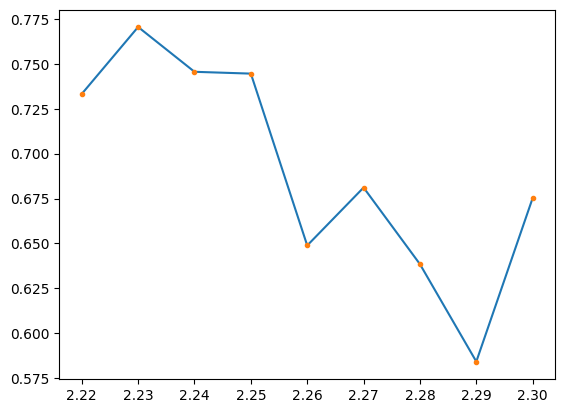

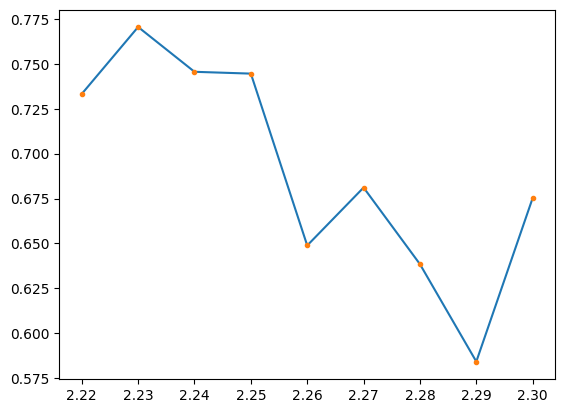

In [105]:
fig1, ax1 = plt.subplots()

# ax.plot(T30_, M30_)
# ax.plot(T40_, M40_)
ax1.plot(T50_, M50_)
# ax.errorbar(T30_, M30_, yerr=err30_, fmt='.', ecolor='red')
# ax.errorbar(T40_, M40_, yerr=err40_, fmt='.', ecolor='red')
ax1.errorbar(T50_, M50_, yerr=err50_, fmt='.', ecolor='red')

fig2, ax2 = plt.subplots()

# ax.plot(T30_, M30_)
# ax.plot(T40_, M40_)
ax2.plot(T50_, M50_)
# ax.errorbar(T30_, M30_, yerr=err30_, fmt='.', ecolor='red')
# ax.errorbar(T40_, M40_, yerr=err40_, fmt='.', ecolor='red')
ax2.errorbar(T50_, M50_, yerr=err50_, fmt='.', ecolor='red')

### Specific Heat

$$ C_v = \sigma_E^2/T^2 $$

where $\sigma_E$ is the std of the energy

Note: we are setting k=1 and J=1

In [86]:
def energy(state):
    # reconstruct shape
    N = len(state)
    L = round(np.sqrt(N))
    state = np.reshape(state, (L,L))
    
    J = 1 # this is what it is for everything
    
    E = 0
    for i,row in enumerate(state):
        for j,spin in enumerate(row):
            
            
            NNa = state[(i-1, j)] # Nearest neighbor above
            NNl = state[(i, j-1)] # Nearest neighbor left
            if i == L-1:
                NNb = state[(0, j)]
            else:
                NNb = state[(i+1, j)]
            if j == L-1:
                NNr = state[(i, 0)]
            else:
                NNr = state[(i, j+1)]
            
            E -= J*spin*(NNb + NNa + NNl + NNr)
    
    return E/2 # we counted each connection twice so we need to divide the energy by 2

def energies(X):
    H = []
    for state in X:
        H.append(energy(state))
    return np.array(H)

def specific_heat(y, energies):
    temperatures = list(set(y))
    
    Cv = []
    for T in temperatures:
        filt = y==T
        energies_ = energies[filt]
        sigma = np.std(energies_)
        Cv.append((sigma/T)**2)
        
    return Cv

In [102]:
X50.shape

(337500, 2500)

In [103]:
t0 = time()
H = energies(X50)
Cv = specific_heat(y50, H)
print(time() - t0)

869.330913066864


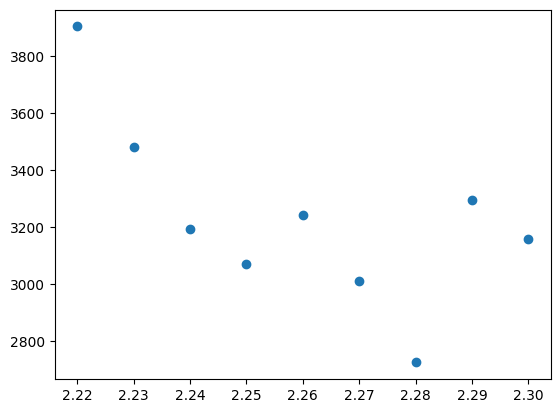

In [104]:
fig, ax = plt.subplots()
T50 = list(set(y50))
ax.scatter(T50, Cv)

### Binder ratios

$$ Q = \frac{<m^2>}{<|m|>^2} $$

In [84]:
def binder(values, y, p=1):
    temperatures = list(set(y))
    squares = values**(2*p)
    absolutes = np.abs(values)**p # aboslutes to the power of p
    
    Q = []
    for kT in temperatures:
        filt = y==kT
        squares_ = squares[filt]
        absolutes_ = absolutes[filt]
        
        q = np.mean(squares_)/(np.mean(absolutes_)**2)
        Q.append(q)
    
    return Q  

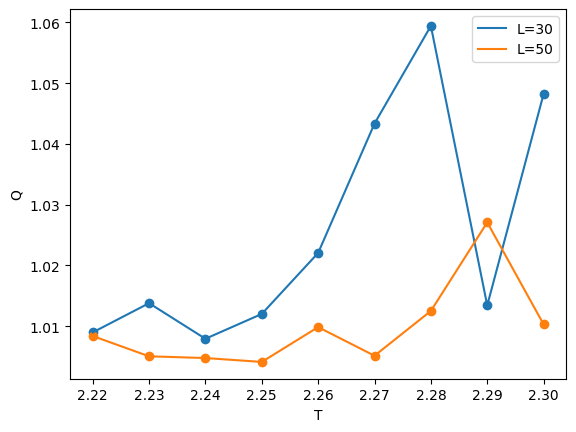

In [85]:
Q30 = binder(m30, y30)
Q40 = binder(m40, y40)
Q50 = binder(m50, y50)

T30_, Q30_ = reorder(T30, Q30)
T40_, Q40_ = reorder(T40, Q40)
T50_, Q50_ = reorder(T50, Q50)

fig, ax = plt.subplots()

ax.scatter(T30_, Q30_)
ax.plot(T30_, Q30_, label="L=30")
# ax.scatter(T40_, Q40_)
# ax.plot(T40_, Q40_, label="L=40")
ax.scatter(T50_, Q50_)
ax.plot(T50_, Q50_, label="L=50")

ax.set_ylabel('Q')
ax.set_xlabel('T')
ax.legend()

# PCA

In [26]:
t1 = time()
reduced_data = PCA(n_components=2).fit_transform(X)
print(time()-t1)
reduced_data.shape

0.5158500671386719


(16720, 2)

In [27]:
p1 = reduced_data[:, 0]
p2 = reduced_data[:, 1]

### Analogy to magnetisation and magnetic susceptibility

In [28]:
p1_mean, err1, temperatures = mean_absolute(p1, y)
p2_mean, err2, temperatures = mean_absolute(p2, y)

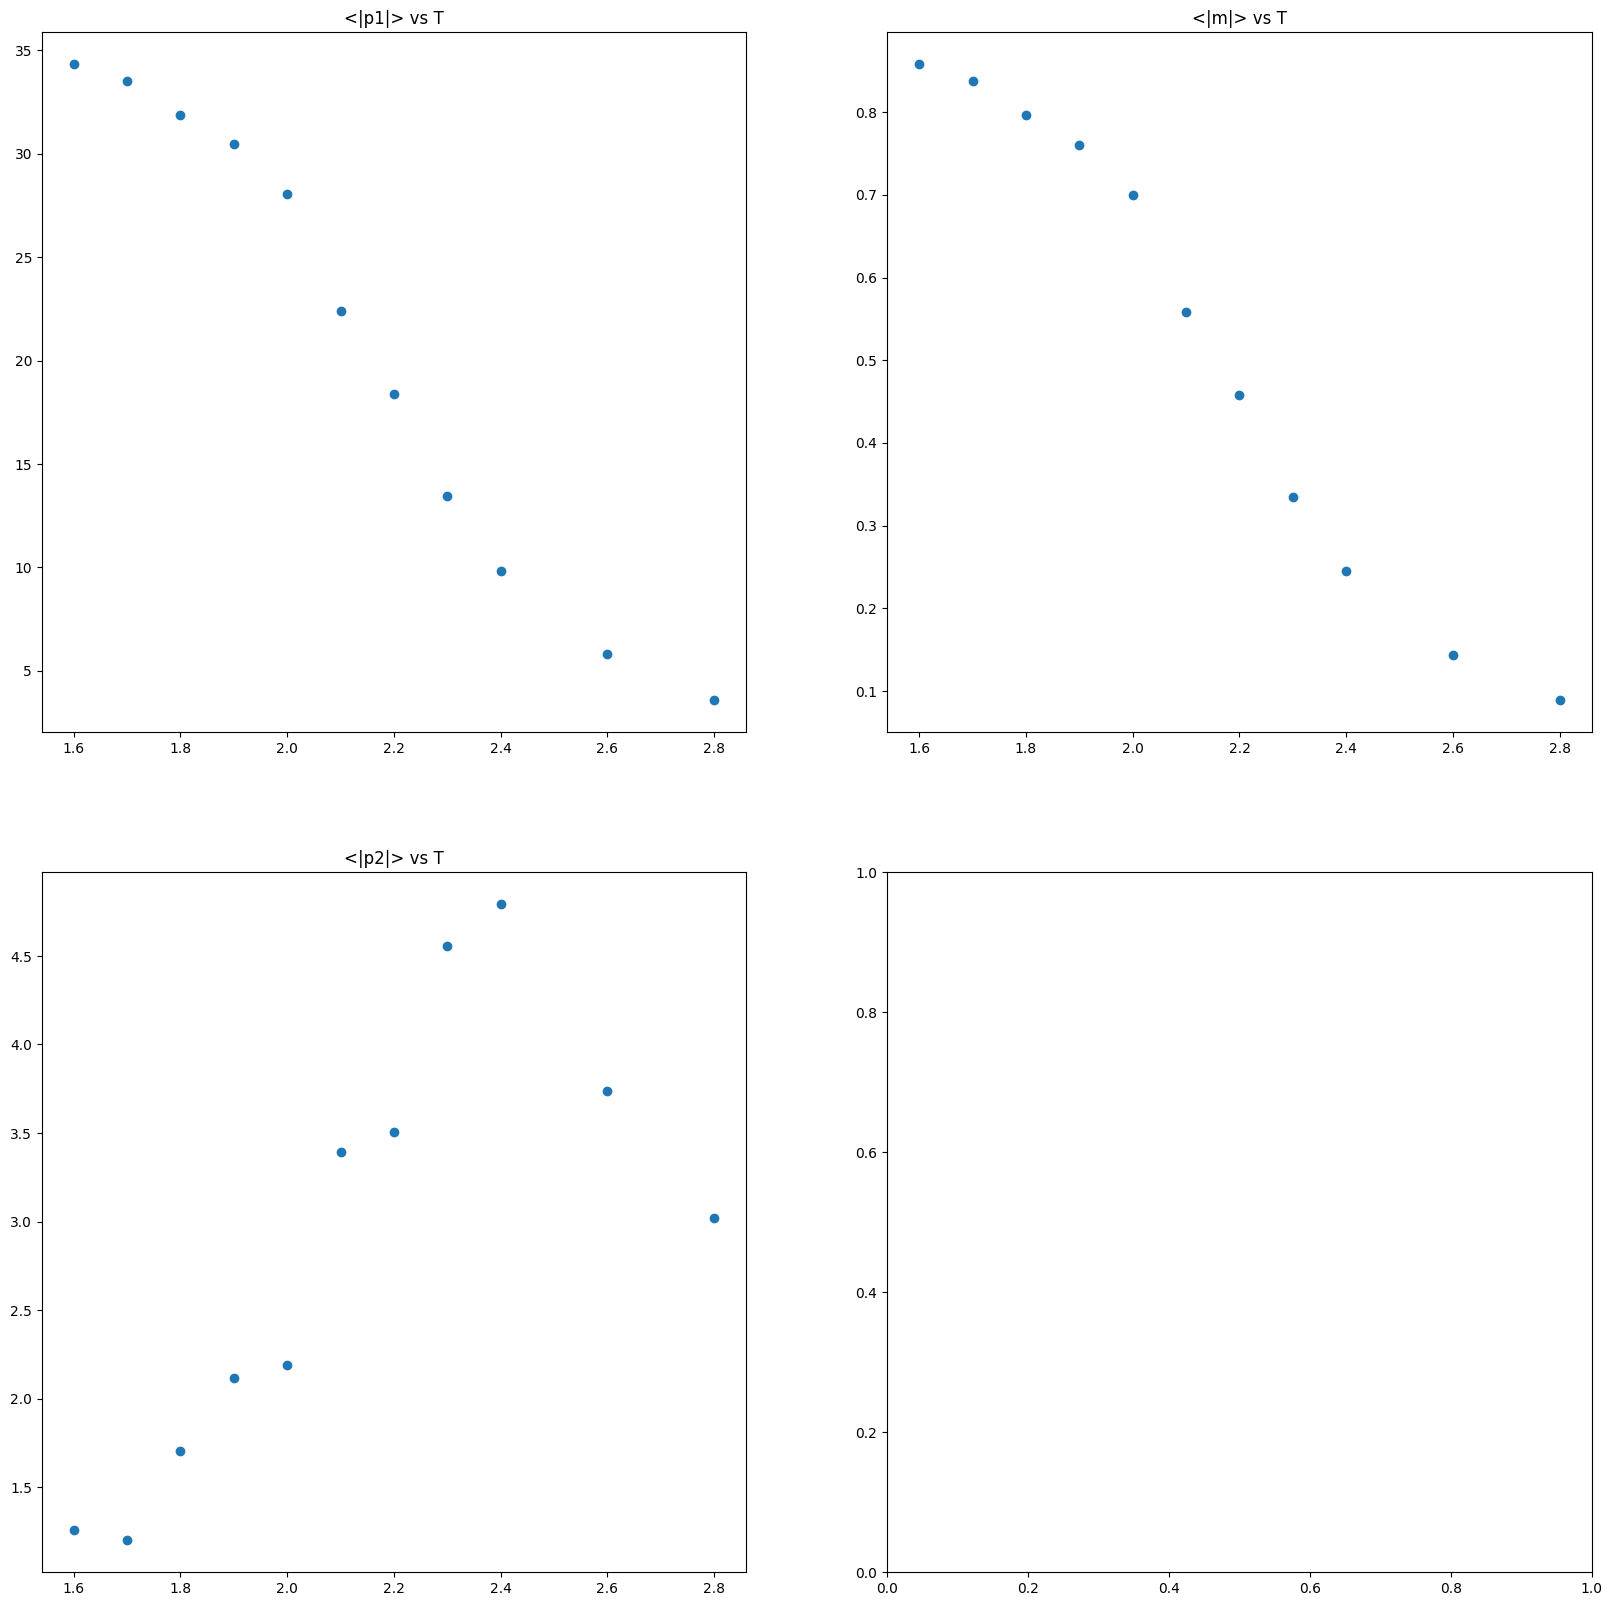

In [29]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(20,20))

axs[0][0].scatter(temperatures, p1_mean)
axs[0][0].set_title('<|p1|> vs T')

axs[0][1].scatter(temperatures, M_mean)
axs[0][1].set_title('<|m|> vs T')

axs[1][0].scatter(temperatures, p2_mean)
axs[1][0].set_title('<|p2|> vs T')

Tc = 2.269
ax.set_xticks(list(ax.get_xticks()) + [2.269])

### Clustering with KMeans

Text(0.5, 0, 'p1')

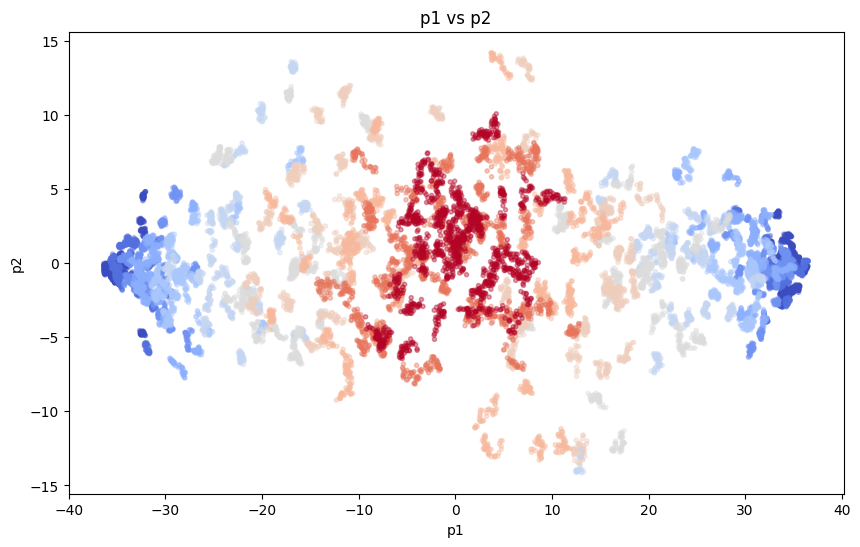

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(p1, p2, c=y, cmap='coolwarm', alpha=0.4, marker='.')
ax.set_title('p1 vs p2')
ax.set_ylabel('p2')
ax.set_xlabel('p1')

# fig.colorbar(cm.ScalarMappable(norm=None, cmap='coolwarm'), ax=ax)

In [34]:
kmeans = KMeans(init="k-means++", n_clusters=3, n_init=4)
kmeans.fit(reduced_data)

KMeans(n_clusters=3, n_init=4)

Text(0.5, 0, 'p1')

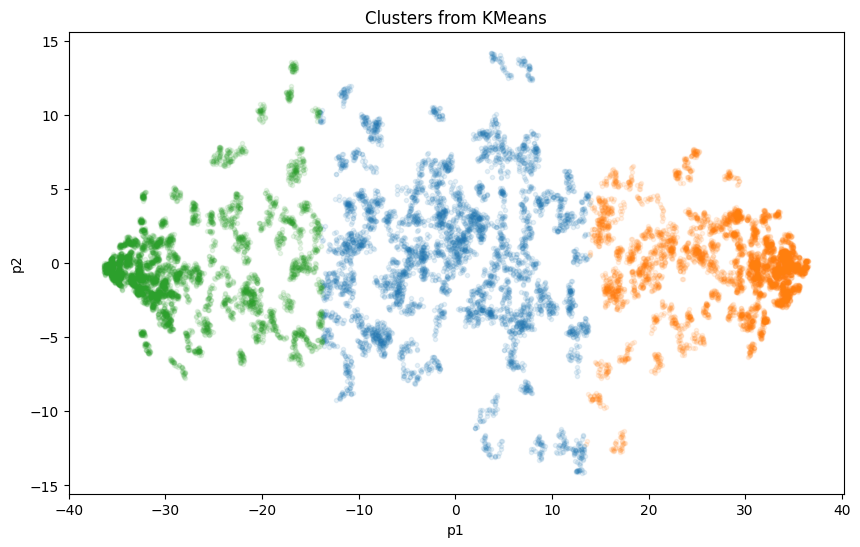

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))

cluster0 = reduced_data[kmeans.labels_ == 0]
cluster1 = reduced_data[kmeans.labels_ == 1]
cluster2 = reduced_data[kmeans.labels_ == 2]

ax.scatter(cluster0[:, 0], cluster0[:, 1], alpha=0.1, marker='.')
ax.scatter(cluster1[:, 0], cluster1[:, 1], alpha=0.1, marker='.')
ax.scatter(cluster2[:, 0], cluster2[:, 1], alpha=0.1, marker='.')

ax.set_title('Clusters from KMeans')
ax.set_ylabel('p2')
ax.set_xlabel('p1')

In [93]:
set(y[kmeans.labels_ == 1])

{2.4, 2.6, 2.8, 3.0}